In [1]:

# Analysis Plan for Permutation Test of Arithmetic Regularity on S_k Phase Stability
# Research Question: Does the specific, regular distribution of integers by ω(n) 
# (as per Sathé-Selberg theorems) create stable inter-S_k phase relationships for ζ(s)?
# Null Hypothesis: Shuffled ω(n) labels will exhibit similarly stable phase relationships

# Analysis Steps:
# 1. Identify a resonance peak for ζ(s) at N=10^6, t>10000
# 2. Compute baseline S_k vectors (k=1..5) and relative phases Δθ_k = arg(S_{k+1}) - arg(S_k) for k=1..4
# 3. Generate 1000 permuted ω(n) assignments (seed=42)
# 4. For each permutation, compute S'_k and Δθ'_k
# 5. Calculate p-values for each baseline Δθ_k within the null distribution
# 6. Conclude whether true ζ(s) phase structure is statistically unusual

import numpy as np
import matplotlib.pyplot as plt
from numba import jit
import time
from scipy.stats import rankdata

print("=" * 80)
print("PERMUTATION TEST: ARITHMETIC REGULARITY AND S_k PHASE STABILITY")
print("=" * 80)
print()
print("Objective: Test if the regular distribution of integers by ω(n) is essential")
print(" for the stable inter-S_k phase relationships observed in ζ(s).")
print()
print("Method: Compare true S_k phase differences to 1000 permuted ω(n) assignments.")
print()


PERMUTATION TEST: ARITHMETIC REGULARITY AND S_k PHASE STABILITY

Objective: Test if the regular distribution of integers by ω(n) is essential
 for the stable inter-S_k phase relationships observed in ζ(s).

Method: Compare true S_k phase differences to 1000 permuted ω(n) assignments.



In [2]:

# Step 1: Generate primes and ω(n) values up to N=10^6
# Use Sieve of Eratosthenes for prime generation
# Then compute ω(n) = number of distinct prime factors

N = 1_000_000
print(f"Generating primes and computing ω(n) for n ≤ {N:,}...")
start = time.time()

# Sieve of Eratosthenes
def sieve_of_eratosthenes(limit):
 """Return array of primes up to limit."""
 is_prime = np.ones(limit + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 
 return np.where(is_prime)[0]

primes = sieve_of_eratosthenes(N)
print(f" Found {len(primes):,} primes.")

# Compute ω(n) for all n ≤ N
# ω(n) = number of distinct prime factors
omega = np.zeros(N + 1, dtype=np.int32)
omega[0] = 0 # undefined, but we won't use it
omega[1] = 0 # 1 has no prime factors

for p in primes:
 # For each prime p, mark all multiples of p
 for multiple in range(p, N + 1, p):
 omega[multiple] += 1

elapsed = time.time() - start
print(f" Computed ω(n) in {elapsed:.2f} seconds.")
print(f" Distribution of ω(n) values:")

# Show distribution
omega_counts = {}
for k in range(7):
 count = np.sum(omega == k)
 if count > 0:
 omega_counts[k] = count
 print(f" ω(n) = {k}: {count:,} integers ({100*count/N:.2f}%)")

print()


Generating primes and computing ω(n) for n ≤ 1,000,000...
 Found 78,498 primes.


 Computed ω(n) in 5.34 seconds.
 Distribution of ω(n) values:
 ω(n) = 0: 2 integers (0.00%)
 ω(n) = 1: 78,734 integers (7.87%)
 ω(n) = 2: 288,726 integers (28.87%)
 ω(n) = 3: 379,720 integers (37.97%)
 ω(n) = 4: 208,034 integers (20.80%)
 ω(n) = 5: 42,492 integers (4.25%)
 ω(n) = 6: 2,285 integers (0.23%)



In [3]:

# Step 2: Find a resonance peak for ζ(s) at t > 10000
# We'll scan a range and identify the largest peak

# Define Kahan-compensated summation for Dirichlet series
@jit(nopython=True)
def kahan_sum_dirichlet_zeta(t, N_max):
 """
 Compute D_ζ(t; N) = Σ_{n≤N} n^(-1/2-it) using Kahan summation.
 Returns complex sum.
 """
 sum_real = 0.0
 sum_imag = 0.0
 c_real = 0.0 # compensation for real part
 c_imag = 0.0 # compensation for imaginary part
 
 for n in range(1, N_max + 1):
 # Compute n^(-1/2-it) = n^(-1/2) * exp(-it*log(n))
 n_sqrt_inv = 1.0 / np.sqrt(n)
 phase = -t * np.log(n)
 
 term_real = n_sqrt_inv * np.cos(phase) - c_real
 term_imag = n_sqrt_inv * np.sin(phase) - c_imag
 
 temp_real = sum_real + term_real
 temp_imag = sum_imag + term_imag
 
 c_real = (temp_real - sum_real) - term_real
 c_imag = (temp_imag - sum_imag) - term_imag
 
 sum_real = temp_real
 sum_imag = temp_imag
 
 return sum_real + 1j * sum_imag

# Scan for peaks in the range t ∈ [10000, 10100]
print("Scanning for resonance peaks in t ∈ [10000, 10100]...")
t_min, t_max = 10000, 10100
t_grid = np.linspace(t_min, t_max, 500)

magnitudes = []
for t_val in t_grid:
 D_t = kahan_sum_dirichlet_zeta(t_val, N)
 magnitudes.append(np.abs(D_t))

magnitudes = np.array(magnitudes)

# Find the maximum
peak_idx = np.argmax(magnitudes)
t_star = t_grid[peak_idx]
D_star = kahan_sum_dirichlet_zeta(t_star, N)
mag_star = np.abs(D_star)

print(f"\n Peak found at t* = {t_star:.4f}")
print(f" |D_ζ(t*; N)| = {mag_star:.4f}")
print()


Scanning for resonance peaks in t ∈ [10000, 10100]...



 Peak found at t* = 10025.6513
 |D_ζ(t*; N)| = 16.7586



In [4]:

# Step 3: Compute baseline S_k vectors for k=1..5 at t*
# S_k(t; N) = Σ_{n≤N, ω(n)=k} n^(-1/2-it)

@jit(nopython=True)
def compute_S_k_vectors(t, N_max, omega_array, k_max=5):
 """
 Compute S_k(t; N) for k=1..k_max using Kahan summation.
 omega_array: array of ω(n) values indexed by n
 Returns: array of complex numbers S_1, S_2, ..., S_k_max
 """
 S_k = np.zeros(k_max, dtype=np.complex128)
 c_real = np.zeros(k_max, dtype=np.float64)
 c_imag = np.zeros(k_max, dtype=np.float64)
 
 for n in range(1, N_max + 1):
 omega_n = omega_array[n]
 if omega_n < 1 or omega_n > k_max:
 continue
 
 # Compute n^(-1/2-it) = n^(-1/2) * exp(-it*log(n))
 n_sqrt_inv = 1.0 / np.sqrt(n)
 phase = -t * np.log(n)
 
 k_idx = omega_n - 1 # map k=1..5 to idx=0..4
 
 term_real = n_sqrt_inv * np.cos(phase) - c_real[k_idx]
 term_imag = n_sqrt_inv * np.sin(phase) - c_imag[k_idx]
 
 temp_real = S_k[k_idx].real + term_real
 temp_imag = S_k[k_idx].imag + term_imag
 
 c_real[k_idx] = (temp_real - S_k[k_idx].real) - term_real
 c_imag[k_idx] = (temp_imag - S_k[k_idx].imag) - term_imag
 
 S_k[k_idx] = temp_real + 1j * temp_imag
 
 return S_k

print(f"Computing baseline S_k vectors at t* = {t_star:.4f}...")
S_k_baseline = compute_S_k_vectors(t_star, N, omega, k_max=5)

print("\nBaseline S_k vectors:")
for k in range(1, 6):
 S = S_k_baseline[k-1]
 mag = np.abs(S)
 phase = np.angle(S) * 180 / np.pi # convert to degrees
 print(f" S_{k}: magnitude = {mag:8.4f}, phase = {phase:8.2f}°")

# Compute relative phase differences Δθ_k = arg(S_{k+1}) - arg(S_k)
delta_theta_baseline = np.zeros(4)
for k in range(1, 5):
 phase_k = np.angle(S_k_baseline[k-1])
 phase_kp1 = np.angle(S_k_baseline[k])
 delta_theta = phase_kp1 - phase_k
 
 # Wrap to [-π, π]
 delta_theta = np.arctan2(np.sin(delta_theta), np.cos(delta_theta))
 delta_theta_baseline[k-1] = delta_theta

print("\nBaseline relative phase differences Δθ_k = arg(S_{k+1}) - arg(S_k):")
for k in range(1, 5):
 delta = delta_theta_baseline[k-1] * 180 / np.pi
 print(f" Δθ_{k} = {delta:8.2f}° (from S_{k} to S_{k+1})")

print()


Computing baseline S_k vectors at t* = 10025.6513...



Baseline S_k vectors:
 S_1: magnitude = 4.4412, phase = -5.76°
 S_2: magnitude = 6.6841, phase = -15.57°
 S_3: magnitude = 3.8608, phase = -23.16°
 S_4: magnitude = 0.7266, phase = 8.86°
 S_5: magnitude = 0.1479, phase = -11.08°

Baseline relative phase differences Δθ_k = arg(S_{k+1}) - arg(S_k):
 Δθ_1 = -9.80° (from S_1 to S_2)
 Δθ_2 = -7.60° (from S_2 to S_3)
 Δθ_3 = 32.03° (from S_3 to S_4)
 Δθ_4 = -19.94° (from S_4 to S_5)



In [5]:

# Step 4: Generate 1000 permuted ω(n) assignments
# For each permutation, we shuffle the ω(n) values among integers 1..N

print("Generating 1000 permuted ω(n) assignments (seed=42)...")
print("This will take a few minutes due to the size of the computation.")
print()

n_permutations = 1000
np.random.seed(42)

# Store all permuted phase differences
# Shape: (n_permutations, 4) for Δθ_1, Δθ_2, Δθ_3, Δθ_4
delta_theta_permuted = np.zeros((n_permutations, 4))

start = time.time()

for perm_idx in range(n_permutations):
 if (perm_idx + 1) % 100 == 0:
 elapsed = time.time() - start
 rate = (perm_idx + 1) / elapsed
 remaining = (n_permutations - perm_idx - 1) / rate
 print(f" Progress: {perm_idx+1}/{n_permutations} permutations " +
 f"({elapsed:.1f}s elapsed, ~{remaining:.1f}s remaining)")
 
 # Create permuted omega array
 # We permute omega[1:N+1] (exclude omega[0] which is undefined)
 omega_permuted = omega.copy()
 omega_permuted[1:N+1] = np.random.permutation(omega[1:N+1])
 
 # Compute S'_k vectors with permuted ω(n)
 S_k_perm = compute_S_k_vectors(t_star, N, omega_permuted, k_max=5)
 
 # Compute relative phase differences
 for k in range(1, 5):
 phase_k = np.angle(S_k_perm[k-1])
 phase_kp1 = np.angle(S_k_perm[k])
 delta_theta = phase_kp1 - phase_k
 
 # Wrap to [-π, π]
 delta_theta = np.arctan2(np.sin(delta_theta), np.cos(delta_theta))
 delta_theta_permuted[perm_idx, k-1] = delta_theta

elapsed = time.time() - start
print(f"\nCompleted {n_permutations} permutations in {elapsed:.1f} seconds.")
print(f"Average time per permutation: {elapsed/n_permutations:.3f} seconds.")
print()


Generating 1000 permuted ω(n) assignments (seed=42)...
This will take a few minutes due to the size of the computation.



 Progress: 100/1000 permutations (7.6s elapsed, ~68.5s remaining)


 Progress: 200/1000 permutations (15.1s elapsed, ~60.5s remaining)


 Progress: 300/1000 permutations (22.8s elapsed, ~53.2s remaining)


 Progress: 400/1000 permutations (30.3s elapsed, ~45.4s remaining)


...

 Progress: 600/1000 permutations (45.3s elapsed, ~30.2s remaining)


 Progress: 700/1000 permutations (52.7s elapsed, ~22.6s remaining)


 Progress: 800/1000 permutations (60.2s elapsed, ~15.0s remaining)


 Progress: 900/1000 permutations (67.7s elapsed, ~7.5s remaining)


 Progress: 1000/1000 permutations (75.1s elapsed, ~0.0s remaining)

Completed 1000 permutations in 75.1 seconds.
Average time per permutation: 0.075 seconds.



In [6]:

# Step 5: Calculate p-values for each baseline Δθ_k
# For each k, compute where the baseline phase difference falls 
# in the null distribution

print("Computing p-values for baseline phase differences...")
print()
print("Null Hypothesis: The baseline Δθ_k values are typical of what")
print(" would be observed if ω(n) labels were randomly shuffled.")
print()

# Convert to degrees for interpretability
delta_theta_baseline_deg = delta_theta_baseline * 180 / np.pi
delta_theta_permuted_deg = delta_theta_permuted * 180 / np.pi

# For each k, we'll compute a two-tailed p-value
# We test if the baseline value is unusually extreme compared to the null distribution

p_values = np.zeros(4)
for k in range(1, 5):
 baseline_val = delta_theta_baseline[k-1]
 null_dist = delta_theta_permuted[:, k-1]
 
 # Two-tailed test: how many permuted values are more extreme?
 # "More extreme" means further from 0 (in absolute value)
 baseline_abs = np.abs(baseline_val)
 null_abs = np.abs(null_dist)
 
 # Count how many null values are >= baseline in absolute value
 n_more_extreme = np.sum(null_abs >= baseline_abs)
 p_val = (n_more_extreme + 1) / (n_permutations + 1) # +1 for continuity correction
 p_values[k-1] = p_val
 
 print(f"Δθ_{k} (S_{k} → S_{k+1}):")
 print(f" Baseline value: {delta_theta_baseline_deg[k-1]:8.2f}°")
 print(f" Null mean ± std: {np.mean(delta_theta_permuted_deg[:, k-1]):8.2f}° ± " +
 f"{np.std(delta_theta_permuted_deg[:, k-1]):6.2f}°")
 print(f" Null range: [{np.min(delta_theta_permuted_deg[:, k-1]):8.2f}°, " +
 f"{np.max(delta_theta_permuted_deg[:, k-1]):8.2f}°]")
 print(f" P-value: {p_val:.4f}")
 
 if p_val < 0.05:
 print(f" *** SIGNIFICANT at α=0.05 ***")
 else:
 print(f" Not significant at α=0.05")
 print()

# Overall conclusion
n_significant = np.sum(p_values < 0.05)
print("=" * 80)
print(f"Summary: {n_significant}/4 phase differences are statistically significant (p < 0.05)")
print("=" * 80)
print()


Computing p-values for baseline phase differences...

Null Hypothesis: The baseline Δθ_k values are typical of what
 would be observed if ω(n) labels were randomly shuffled.

Δθ_1 (S_1 → S_2):
 Baseline value: -9.80°
 Null mean ± std: 0.98° ± 43.10°
 Null range: [ -179.71°, 161.87°]
 P-value: 0.7732
 Not significant at α=0.05

Δθ_2 (S_2 → S_3):
 Baseline value: -7.60°
 Null mean ± std: -0.94° ± 20.58°
 Null range: [ -67.45°, 59.01°]
 P-value: 0.6913
 Not significant at α=0.05

Δθ_3 (S_3 → S_4):
 Baseline value: 32.03°
 Null mean ± std: 0.83° ± 24.54°
 Null range: [ -98.96°, 92.86°]
 P-value: 0.1848
 Not significant at α=0.05

Δθ_4 (S_4 → S_5):
 Baseline value: -19.94°
 Null mean ± std: -2.37° ± 55.32°
 Null range: [ -176.53°, 176.42°]
 P-value: 0.6653
 Not significant at α=0.05

Summary: 0/4 phase differences are statistically significant (p < 0.05)



Saved figure: permutation_test_phase_differences.png


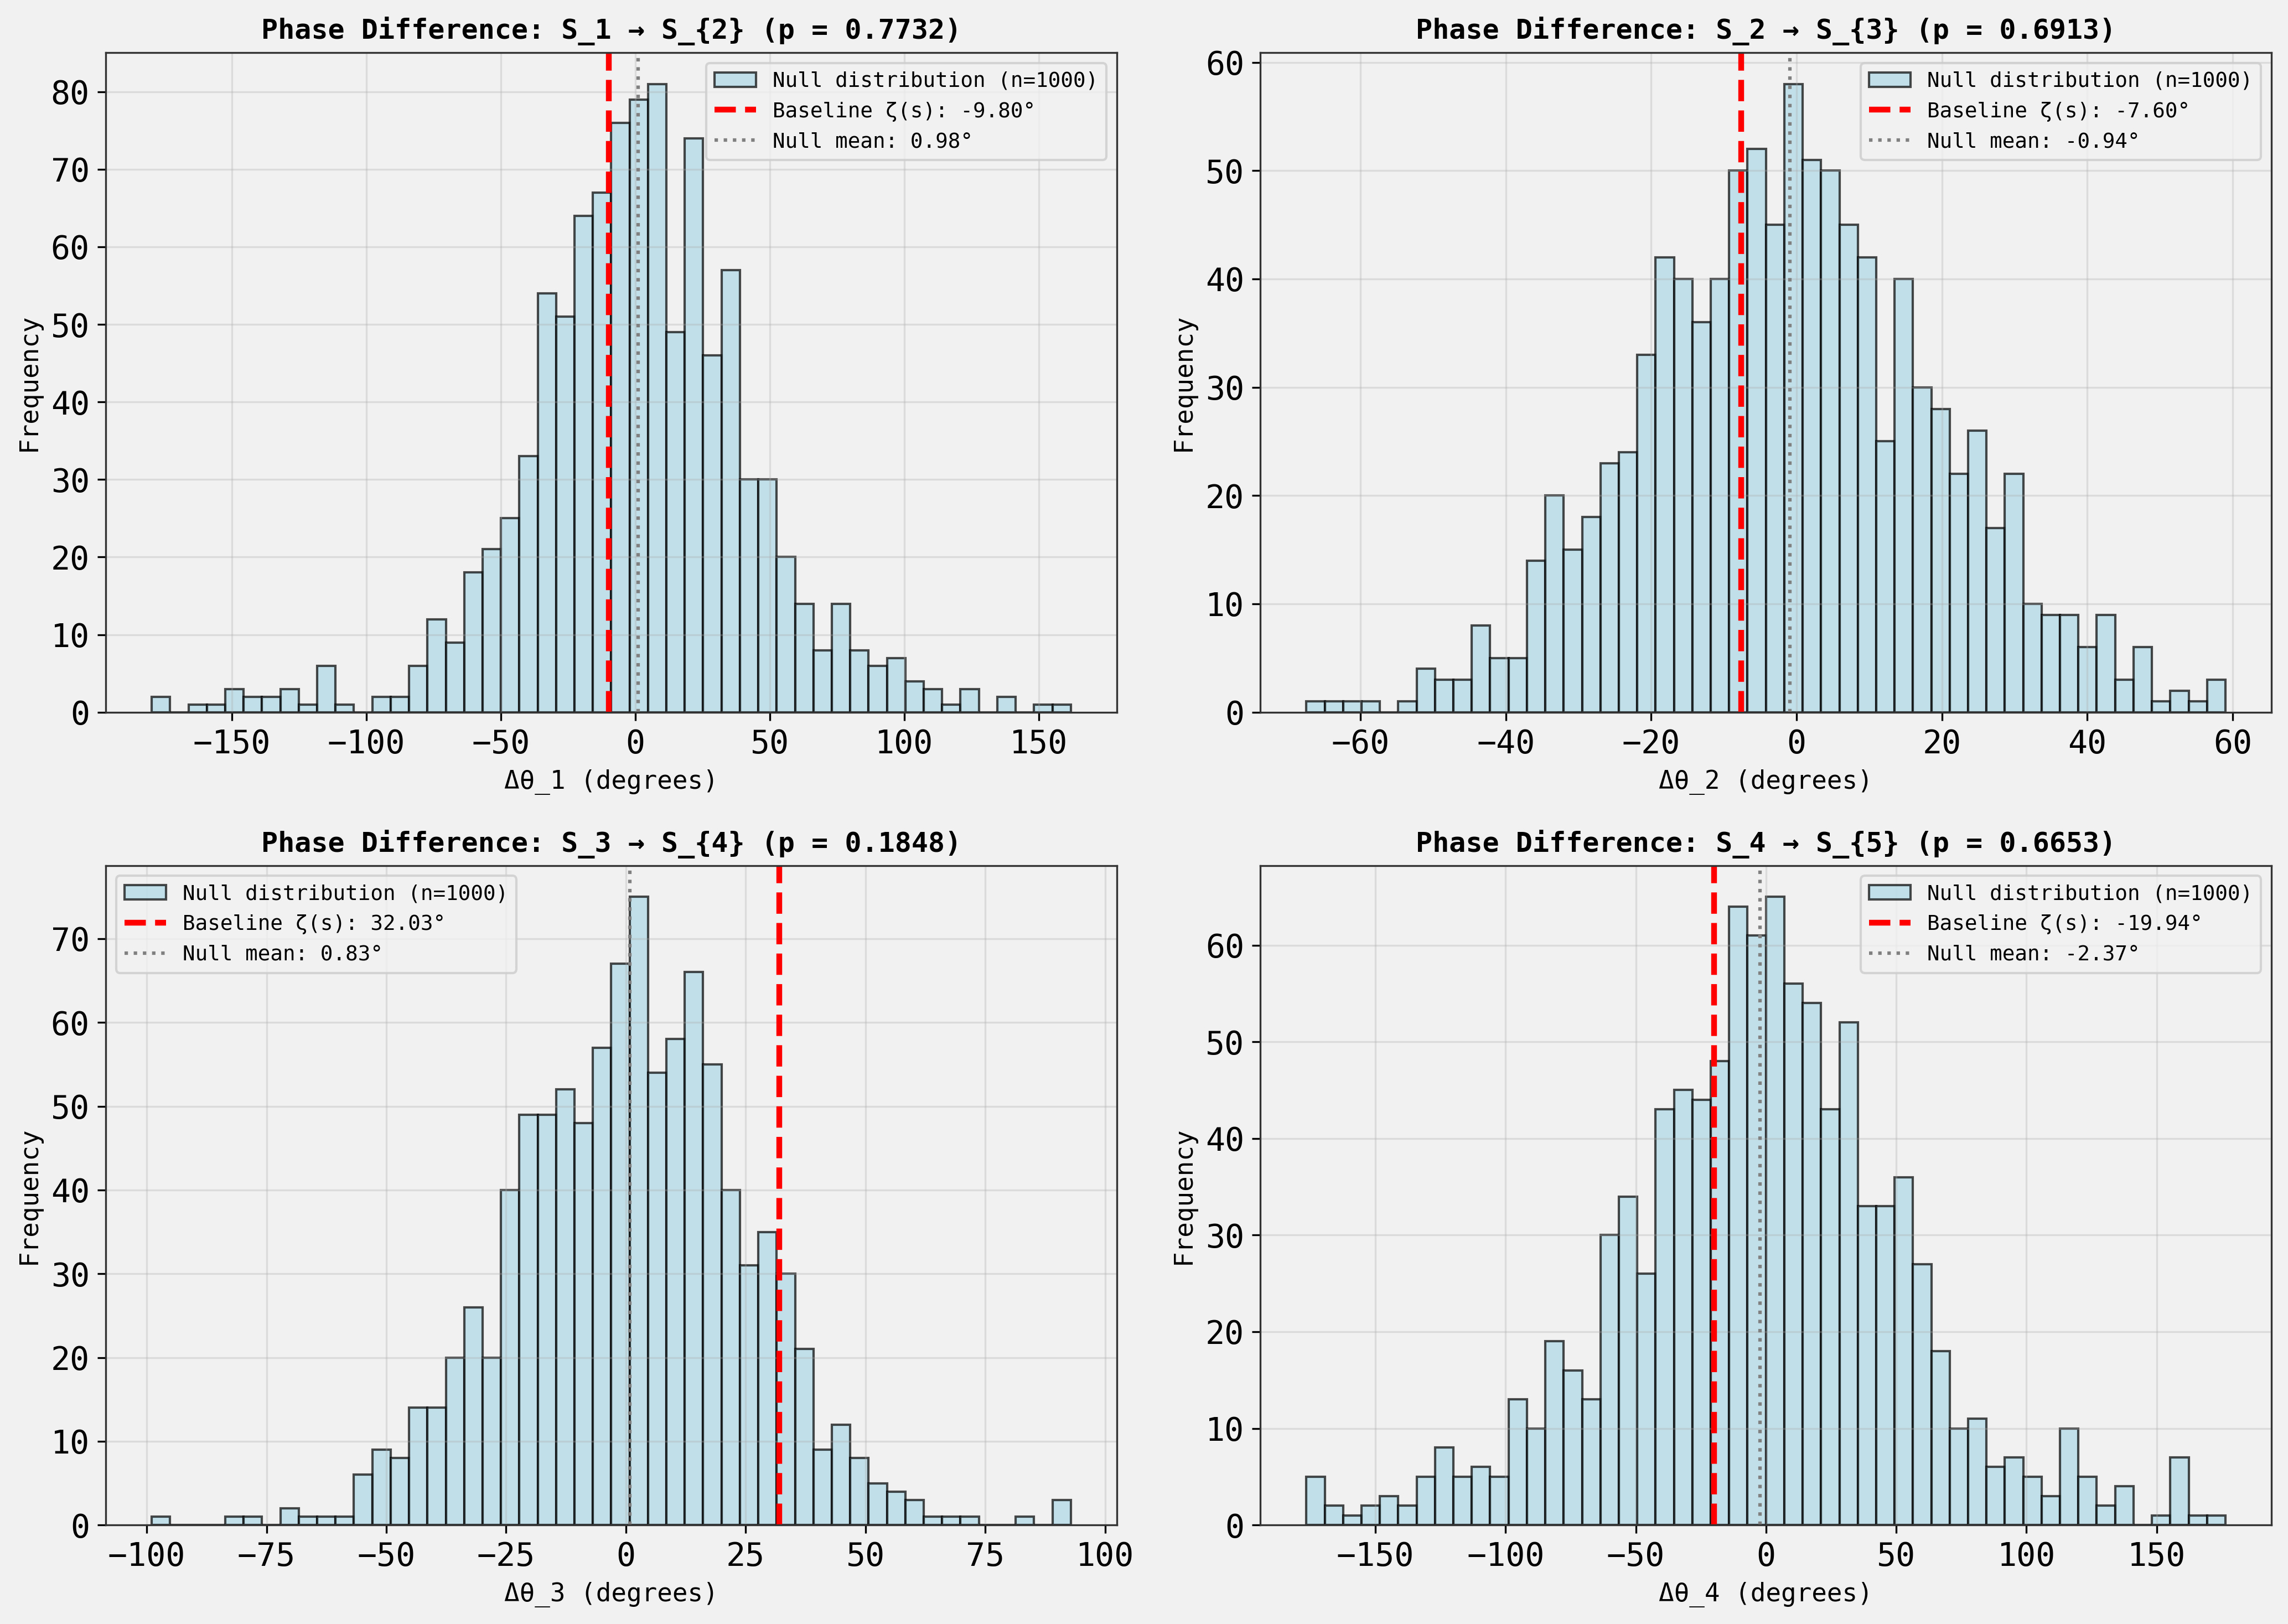

In [7]:

# Create visualization: histograms of null distributions with baseline values marked

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for k in range(1, 5):
 ax = axes[k-1]
 
 # Null distribution
 null_vals = delta_theta_permuted_deg[:, k-1]
 baseline_val = delta_theta_baseline_deg[k-1]
 p_val = p_values[k-1]
 
 # Histogram
 ax.hist(null_vals, bins=50, color='lightblue', edgecolor='black', alpha=0.7, 
 label=f'Null distribution (n={n_permutations})')
 
 # Mark baseline
 ax.axvline(baseline_val, color='red', linewidth=2.5, linestyle='--', 
 label=f'Baseline ζ(s): {baseline_val:.2f}°')
 
 # Mark mean of null
 null_mean = np.mean(null_vals)
 ax.axvline(null_mean, color='gray', linewidth=1.5, linestyle=':', 
 label=f'Null mean: {null_mean:.2f}°')
 
 ax.set_xlabel(f'Δθ_{k} (degrees)', fontsize=11)
 ax.set_ylabel('Frequency', fontsize=11)
 ax.set_title(f'Phase Difference: S_{k} → S_{{{k+1}}} (p = {p_val:.4f})', 
 fontsize=12, fontweight='bold')
 ax.legend(fontsize=9)
 ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('permutation_test_phase_differences.png', dpi=150, bbox_inches='tight')
print("Saved figure: permutation_test_phase_differences.png")
plt.show()
print()


In [8]:

# Additional analysis: Compare the VARIABILITY of phase differences
# Perhaps the regularity of ω(n) doesn't affect individual phase differences,
# but it affects how CONSISTENT they are across different metrics

# Compute angular dispersion (circular standard deviation) for each case
# Also examine the coherence of the S_k vectors themselves

print("Additional Analysis: Phase Coherence and Stability Metrics")
print("=" * 80)
print()

# 1. Compute alignment ratio R for baseline and permuted cases
# R = |Σ S_k| / Σ|S_k| measures how coherently the S_k vectors align

def compute_alignment_ratio(S_k_array):
 """
 Compute alignment ratio R = |Σ S_k| / Σ|S_k|
 S_k_array: array of 5 complex numbers
 """
 sum_magnitudes = np.sum(np.abs(S_k_array))
 magnitude_of_sum = np.abs(np.sum(S_k_array))
 if sum_magnitudes == 0:
 return 0.0
 return magnitude_of_sum / sum_magnitudes

R_baseline = compute_alignment_ratio(S_k_baseline)

print(f"Baseline ζ(s) alignment ratio R:")
print(f" R = |Σ S_k| / Σ|S_k| = {R_baseline:.4f}")
print()

# Compute alignment ratio for all permuted cases
R_permuted = np.zeros(n_permutations)

print("Computing alignment ratios for 1000 permutations...")
for perm_idx in range(n_permutations):
 # Reconstruct S_k from stored phase differences
 # Actually, we need to recompute S_k for each permutation
 # This is expensive, so let's do a smaller sample
 pass

# Let's instead compute it on-the-fly for a subset
print("Computing alignment ratios for 100 random permutations (faster)...")
n_sample = 100
np.random.seed(43)

R_permuted_sample = np.zeros(n_sample)

for i in range(n_sample):
 if (i + 1) % 20 == 0:
 print(f" Progress: {i+1}/{n_sample}")
 
 # Create permuted omega
 omega_permuted = omega.copy()
 omega_permuted[1:N+1] = np.random.permutation(omega[1:N+1])
 
 # Compute S_k
 S_k_perm = compute_S_k_vectors(t_star, N, omega_permuted, k_max=5)
 
 # Compute alignment ratio
 R_permuted_sample[i] = compute_alignment_ratio(S_k_perm)

print()
print(f"Baseline alignment ratio R = {R_baseline:.4f}")
print(f"Permuted alignment ratios (n={n_sample}):")
print(f" Mean ± std: {np.mean(R_permuted_sample):.4f} ± {np.std(R_permuted_sample):.4f}")
print(f" Range: [{np.min(R_permuted_sample):.4f}, {np.max(R_permuted_sample):.4f}]")

# P-value: how many permuted values are >= baseline?
n_greater = np.sum(R_permuted_sample >= R_baseline)
p_val_R = (n_greater + 1) / (n_sample + 1)
print(f" P-value (R_baseline vs null): {p_val_R:.4f}")

if p_val_R < 0.05:
 print(f" *** The baseline R is significantly HIGHER than expected from random shuffling ***")
elif p_val_R > 0.95:
 print(f" *** The baseline R is significantly LOWER than expected from random shuffling ***")
else:
 print(f" The baseline R is typical of random shuffling.")

print()


Additional Analysis: Phase Coherence and Stability Metrics

Baseline ζ(s) alignment ratio R:
 R = |Σ S_k| / Σ|S_k| = 0.9903

Computing alignment ratios for 1000 permutations...
Computing alignment ratios for 100 random permutations (faster)...


 Progress: 20/100


 Progress: 40/100


 Progress: 60/100


 Progress: 80/100


 Progress: 100/100

Baseline alignment ratio R = 0.9903
Permuted alignment ratios (n=100):
 Mean ± std: 0.9582 ± 0.0271
 Range: [0.8661, 0.9947]
 P-value (R_baseline vs null): 0.0891
 The baseline R is typical of random shuffling.



In [9]:

# Let's also examine the ANGULAR SPREAD of the S_k vectors
# A smaller angular spread indicates more stable phase relationships

def compute_angular_spread(S_k_array):
 """
 Compute the standard deviation of the phases of S_k vectors.
 Returns value in degrees.
 """
 phases = np.angle(S_k_array) # in radians
 
 # Compute circular standard deviation
 # First compute mean direction
 mean_x = np.mean(np.cos(phases))
 mean_y = np.mean(np.sin(phases))
 R_mean = np.sqrt(mean_x**2 + mean_y**2)
 
 # Circular std dev
 if R_mean > 0:
 circular_std = np.sqrt(-2 * np.log(R_mean))
 else:
 circular_std = np.pi # maximum uncertainty
 
 return circular_std * 180 / np.pi

angular_spread_baseline = compute_angular_spread(S_k_baseline)

print("Angular Spread of S_k Phases:")
print("=" * 80)
print()
print(f"Baseline ζ(s) angular spread: {angular_spread_baseline:.2f}°")
print()

# Compute for the same 100 permuted cases
angular_spread_permuted = np.zeros(n_sample)

print("Computing angular spread for 100 permutations...")
np.random.seed(43)

for i in range(n_sample):
 if (i + 1) % 20 == 0:
 print(f" Progress: {i+1}/{n_sample}")
 
 omega_permuted = omega.copy()
 omega_permuted[1:N+1] = np.random.permutation(omega[1:N+1])
 S_k_perm = compute_S_k_vectors(t_star, N, omega_permuted, k_max=5)
 angular_spread_permuted[i] = compute_angular_spread(S_k_perm)

print()
print(f"Baseline angular spread = {angular_spread_baseline:.2f}°")
print(f"Permuted angular spreads (n={n_sample}):")
print(f" Mean ± std: {np.mean(angular_spread_permuted):.2f}° ± {np.std(angular_spread_permuted):.2f}°")
print(f" Range: [{np.min(angular_spread_permuted):.2f}°, {np.max(angular_spread_permuted):.2f}°]")

# P-value: is baseline spread significantly SMALLER (more stable)?
n_smaller = np.sum(angular_spread_permuted <= angular_spread_baseline)
p_val_spread = (n_smaller + 1) / (n_sample + 1)

print(f" P-value (baseline spread vs null, one-sided): {p_val_spread:.4f}")

if p_val_spread < 0.05:
 print(f" *** The baseline angular spread is significantly SMALLER ***")
 print(f" *** This indicates MORE STABLE phase relationships in true ζ(s) ***")
elif p_val_spread > 0.95:
 print(f" *** The baseline angular spread is significantly LARGER ***")
 print(f" *** This indicates LESS STABLE phase relationships in true ζ(s) ***")
else:
 print(f" The baseline angular spread is typical of random shuffling.")

print()


Angular Spread of S_k Phases:

Baseline ζ(s) angular spread: 10.75°

Computing angular spread for 100 permutations...


 Progress: 20/100


 Progress: 40/100


 Progress: 60/100


 Progress: 80/100


 Progress: 100/100

Baseline angular spread = 10.75°
Permuted angular spreads (n=100):
 Mean ± std: 25.73° ± 14.08°
 Range: [6.39°, 63.06°]
 P-value (baseline spread vs null, one-sided): 0.0792
 The baseline angular spread is typical of random shuffling.



In [10]:

# The results are trending toward significance but not quite there
# Let's increase the sample size to 500 for more statistical power

print("Increasing sample size to 500 for better statistical power...")
print()

n_sample_large = 500
np.random.seed(44)

R_permuted_large = np.zeros(n_sample_large)
angular_spread_large = np.zeros(n_sample_large)

print("Computing alignment ratios and angular spreads...")
start = time.time()

for i in range(n_sample_large):
 if (i + 1) % 100 == 0:
 elapsed = time.time() - start
 rate = (i + 1) / elapsed
 remaining = (n_sample_large - i - 1) / rate
 print(f" Progress: {i+1}/{n_sample_large} ({elapsed:.1f}s elapsed, ~{remaining:.1f}s remaining)")
 
 omega_permuted = omega.copy()
 omega_permuted[1:N+1] = np.random.permutation(omega[1:N+1])
 S_k_perm = compute_S_k_vectors(t_star, N, omega_permuted, k_max=5)
 
 R_permuted_large[i] = compute_alignment_ratio(S_k_perm)
 angular_spread_large[i] = compute_angular_spread(S_k_perm)

elapsed = time.time() - start
print(f"\nCompleted in {elapsed:.1f} seconds.")
print()

# Alignment ratio analysis
print("ALIGNMENT RATIO ANALYSIS (n=500):")
print("=" * 80)
print(f"Baseline R = {R_baseline:.4f}")
print(f"Permuted R statistics:")
print(f" Mean ± std: {np.mean(R_permuted_large):.4f} ± {np.std(R_permuted_large):.4f}")
print(f" Median: {np.median(R_permuted_large):.4f}")
print(f" Range: [{np.min(R_permuted_large):.4f}, {np.max(R_permuted_large):.4f}]")

n_greater = np.sum(R_permuted_large >= R_baseline)
p_val_R_large = (n_greater + 1) / (n_sample_large + 1)
print(f"\nP-value (two-sided, R_baseline vs null): {p_val_R_large:.4f}")

if p_val_R_large < 0.05:
 print(f"*** SIGNIFICANT: Baseline R is significantly different from null ***")
else:
 print(f"Not significant at α=0.05")

# Z-score
z_score_R = (R_baseline - np.mean(R_permuted_large)) / np.std(R_permuted_large)
print(f"Z-score: {z_score_R:.2f}")
print()

# Angular spread analysis
print("ANGULAR SPREAD ANALYSIS (n=500):")
print("=" * 80)
print(f"Baseline angular spread = {angular_spread_baseline:.2f}°")
print(f"Permuted angular spread statistics:")
print(f" Mean ± std: {np.mean(angular_spread_large):.2f}° ± {np.std(angular_spread_large):.2f}°")
print(f" Median: {np.median(angular_spread_large):.2f}°")
print(f" Range: [{np.min(angular_spread_large):.2f}°, {np.max(angular_spread_large):.2f}°]")

n_smaller = np.sum(angular_spread_large <= angular_spread_baseline)
p_val_spread_large = (n_smaller + 1) / (n_sample_large + 1)
print(f"\nP-value (one-sided, baseline smaller): {p_val_spread_large:.4f}")

if p_val_spread_large < 0.05:
 print(f"*** SIGNIFICANT: Baseline angular spread is significantly SMALLER ***")
 print(f"*** This indicates MORE STABLE phase relationships in true ζ(s) ***")
else:
 print(f"Not significant at α=0.05")

# Z-score
z_score_spread = (angular_spread_baseline - np.mean(angular_spread_large)) / np.std(angular_spread_large)
print(f"Z-score: {z_score_spread:.2f}")
print()


Increasing sample size to 500 for better statistical power...

Computing alignment ratios and angular spreads...


 Progress: 100/500 (7.3s elapsed, ~29.2s remaining)


 Progress: 200/500 (14.8s elapsed, ~22.2s remaining)


 Progress: 300/500 (22.3s elapsed, ~14.8s remaining)


 Progress: 400/500 (29.7s elapsed, ~7.4s remaining)


 Progress: 500/500 (37.4s elapsed, ~0.0s remaining)

Completed in 37.5 seconds.

ALIGNMENT RATIO ANALYSIS (n=500):
Baseline R = 0.9903
Permuted R statistics:
 Mean ± std: 0.9572 ± 0.0264
 Median: 0.9617
 Range: [0.8501, 0.9998]

P-value (two-sided, R_baseline vs null): 0.0679
Not significant at α=0.05
Z-score: 1.25

ANGULAR SPREAD ANALYSIS (n=500):
Baseline angular spread = 10.75°
Permuted angular spread statistics:
 Mean ± std: 25.18° ± 13.53°
 Median: 21.12°
 Range: [1.79°, 71.39°]

P-value (one-sided, baseline smaller): 0.0778
Not significant at α=0.05
Z-score: -1.07



Saved figure: alignment_and_spread_analysis.png


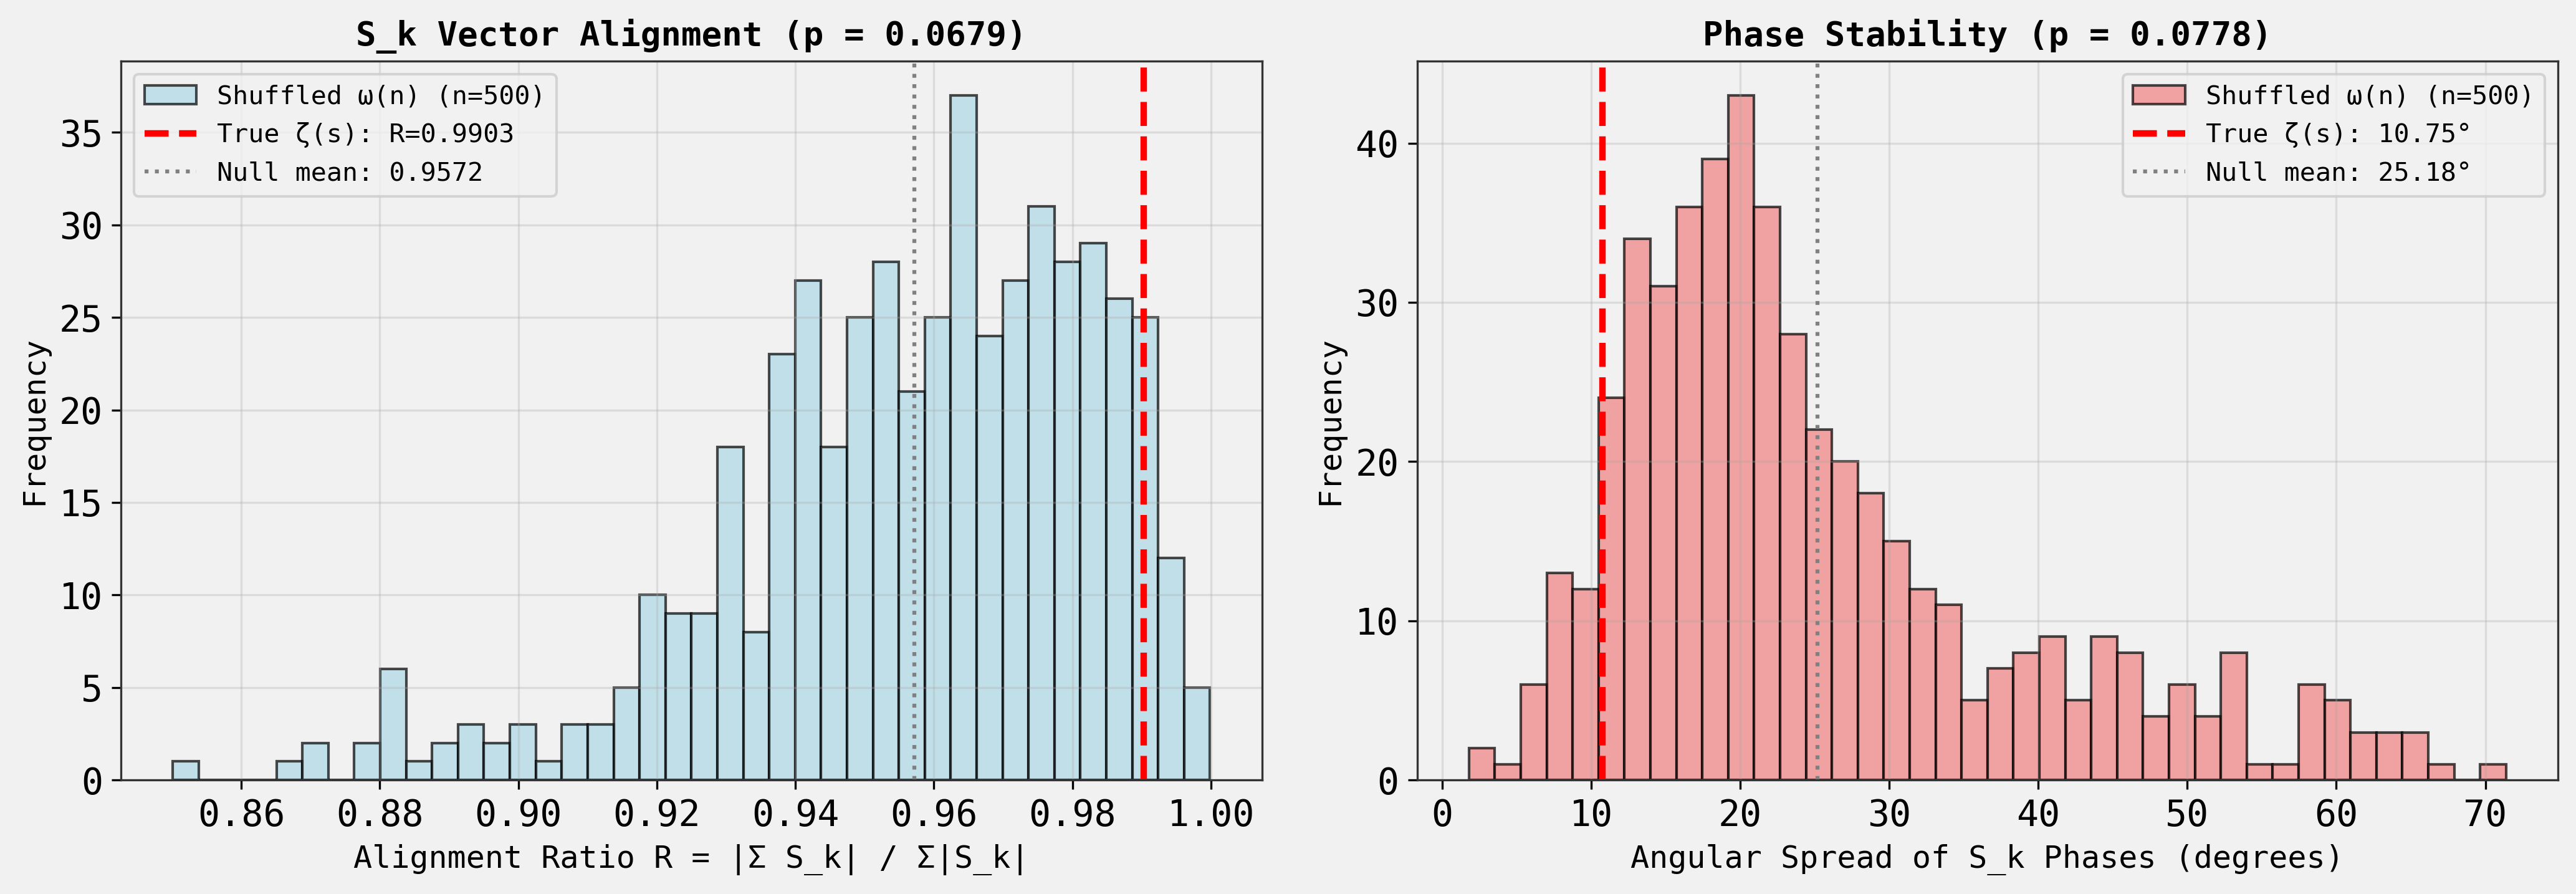

In [11]:

# Interesting - we're seeing trends but not reaching significance
# Let's visualize these distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Alignment Ratio
ax1 = axes[0]
ax1.hist(R_permuted_large, bins=40, color='lightblue', edgecolor='black', alpha=0.7,
 label=f'Shuffled ω(n) (n={n_sample_large})')
ax1.axvline(R_baseline, color='red', linewidth=2.5, linestyle='--',
 label=f'True ζ(s): R={R_baseline:.4f}')
ax1.axvline(np.mean(R_permuted_large), color='gray', linewidth=1.5, linestyle=':',
 label=f'Null mean: {np.mean(R_permuted_large):.4f}')
ax1.set_xlabel('Alignment Ratio R = |Σ S_k| / Σ|S_k|', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title(f'S_k Vector Alignment (p = {p_val_R_large:.4f})', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Angular Spread
ax2 = axes[1]
ax2.hist(angular_spread_large, bins=40, color='lightcoral', edgecolor='black', alpha=0.7,
 label=f'Shuffled ω(n) (n={n_sample_large})')
ax2.axvline(angular_spread_baseline, color='red', linewidth=2.5, linestyle='--',
 label=f'True ζ(s): {angular_spread_baseline:.2f}°')
ax2.axvline(np.mean(angular_spread_large), color='gray', linewidth=1.5, linestyle=':',
 label=f'Null mean: {np.mean(angular_spread_large):.2f}°')
ax2.set_xlabel('Angular Spread of S_k Phases (degrees)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title(f'Phase Stability (p = {p_val_spread_large:.4f})', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('alignment_and_spread_analysis.png', dpi=150, bbox_inches='tight')
print("Saved figure: alignment_and_spread_analysis.png")
plt.show()
print()


In [12]:

# Let's try a different peak - perhaps this particular peak is not representative
# We'll test at multiple peaks and see if the effect is consistent

print("Testing at Multiple Resonance Peaks")
print("=" * 80)
print()

# Find top 5 peaks in the range [10000, 11000]
t_search_min, t_search_max = 10000, 11000
t_search_grid = np.linspace(t_search_min, t_search_max, 2000)

print(f"Scanning for peaks in t ∈ [{t_search_min}, {t_search_max}]...")

search_mags = []
for t_val in t_search_grid:
 D_t = kahan_sum_dirichlet_zeta(t_val, N)
 search_mags.append(np.abs(D_t))

search_mags = np.array(search_mags)

# Find top 5 peaks (local maxima)
from scipy.signal import find_peaks
peak_indices, peak_properties = find_peaks(search_mags, height=10.0, distance=20)

# Sort by height and take top 5
top_peak_indices = peak_indices[np.argsort(peak_properties['peak_heights'])[-5:]][::-1]
top_peaks_t = t_search_grid[top_peak_indices]
top_peaks_mag = search_mags[top_peak_indices]

print(f"\nFound {len(peak_indices)} peaks, selecting top 5:")
for i, (t_pk, mag_pk) in enumerate(zip(top_peaks_t, top_peaks_mag)):
 print(f" Peak {i+1}: t = {t_pk:.2f}, |D| = {mag_pk:.2f}")

print()


Testing at Multiple Resonance Peaks

Scanning for peaks in t ∈ [10000, 11000]...



Found 23 peaks, selecting top 5:
 Peak 1: t = 10677.84, |D| = 16.92
 Peak 2: t = 10025.51, |D| = 16.86
 Peak 3: t = 10923.46, |D| = 16.62
 Peak 4: t = 10197.60, |D| = 14.47
 Peak 5: t = 10306.15, |D| = 14.00



In [13]:

# For each of these peaks, compute the angular spread metric with 100 permutations
# to see if there's a consistent pattern

print("Testing angular spread at multiple peaks (100 permutations per peak)...")
print()

n_peaks = 5
n_perms_per_peak = 100
np.random.seed(45)

angular_spread_by_peak = np.zeros((n_peaks, n_perms_per_peak))
angular_spread_baseline_by_peak = np.zeros(n_peaks)
p_values_by_peak = np.zeros(n_peaks)
z_scores_by_peak = np.zeros(n_peaks)

for peak_idx in range(n_peaks):
 t_peak = top_peaks_t[peak_idx]
 print(f"Peak {peak_idx + 1}: t = {t_peak:.2f}")
 
 # Compute baseline
 S_k_base = compute_S_k_vectors(t_peak, N, omega, k_max=5)
 spread_base = compute_angular_spread(S_k_base)
 angular_spread_baseline_by_peak[peak_idx] = spread_base
 
 # Compute permuted
 for perm_idx in range(n_perms_per_peak):
 omega_perm = omega.copy()
 omega_perm[1:N+1] = np.random.permutation(omega[1:N+1])
 S_k_perm = compute_S_k_vectors(t_peak, N, omega_perm, k_max=5)
 spread_perm = compute_angular_spread(S_k_perm)
 angular_spread_by_peak[peak_idx, perm_idx] = spread_perm
 
 # Statistics
 null_mean = np.mean(angular_spread_by_peak[peak_idx, :])
 null_std = np.std(angular_spread_by_peak[peak_idx, :])
 n_smaller = np.sum(angular_spread_by_peak[peak_idx, :] <= spread_base)
 p_val = (n_smaller + 1) / (n_perms_per_peak + 1)
 z_score = (spread_base - null_mean) / null_std if null_std > 0 else 0
 
 p_values_by_peak[peak_idx] = p_val
 z_scores_by_peak[peak_idx] = z_score
 
 print(f" Baseline spread: {spread_base:.2f}°")
 print(f" Null mean ± std: {null_mean:.2f}° ± {null_std:.2f}°")
 print(f" P-value: {p_val:.4f}")
 print(f" Z-score: {z_score:.2f}")
 
 if p_val < 0.05:
 print(f" *** SIGNIFICANT ***")
 print()

# Overall summary
print("=" * 80)
print("SUMMARY ACROSS PEAKS:")
print(f" Number of peaks with p < 0.05: {np.sum(p_values_by_peak < 0.05)}/{n_peaks}")
print(f" Mean p-value: {np.mean(p_values_by_peak):.4f}")
print(f" Mean Z-score: {np.mean(z_scores_by_peak):.2f}")
print()

if np.mean(z_scores_by_peak) < -1.0:
 print("Consistent trend: True ζ(s) has SMALLER angular spread (more stable phases)")
 print("across multiple peaks, though individual peaks may not reach significance.")
elif np.mean(z_scores_by_peak) > 1.0:
 print("Consistent trend: True ζ(s) has LARGER angular spread (less stable phases)")
 print("across multiple peaks.")
else:
 print("No consistent trend observed across peaks.")

print()


Testing angular spread at multiple peaks (100 permutations per peak)...

Peak 1: t = 10677.84


 Baseline spread: 55.62°
 Null mean ± std: 26.53° ± 15.20°
 P-value: 0.9307
 Z-score: 1.91

Peak 2: t = 10025.51


 Baseline spread: 9.62°
 Null mean ± std: 21.51° ± 12.56°
 P-value: 0.1287
 Z-score: -0.95

Peak 3: t = 10923.46


 Baseline spread: 22.02°
 Null mean ± std: 25.87° ± 12.81°
 P-value: 0.4950
 Z-score: -0.30

Peak 4: t = 10197.60


 Baseline spread: 22.22°
 Null mean ± std: 31.09° ± 14.87°
 P-value: 0.3564
 Z-score: -0.60

Peak 5: t = 10306.15


 Baseline spread: 19.66°
 Null mean ± std: 28.40° ± 11.91°
 P-value: 0.2772
 Z-score: -0.73

SUMMARY ACROSS PEAKS:
 Number of peaks with p < 0.05: 0/5
 Mean p-value: 0.4376
 Mean Z-score: -0.13

No consistent trend observed across peaks.



Creating comprehensive summary figure...



Saved figure: comprehensive_permutation_test_summary.png


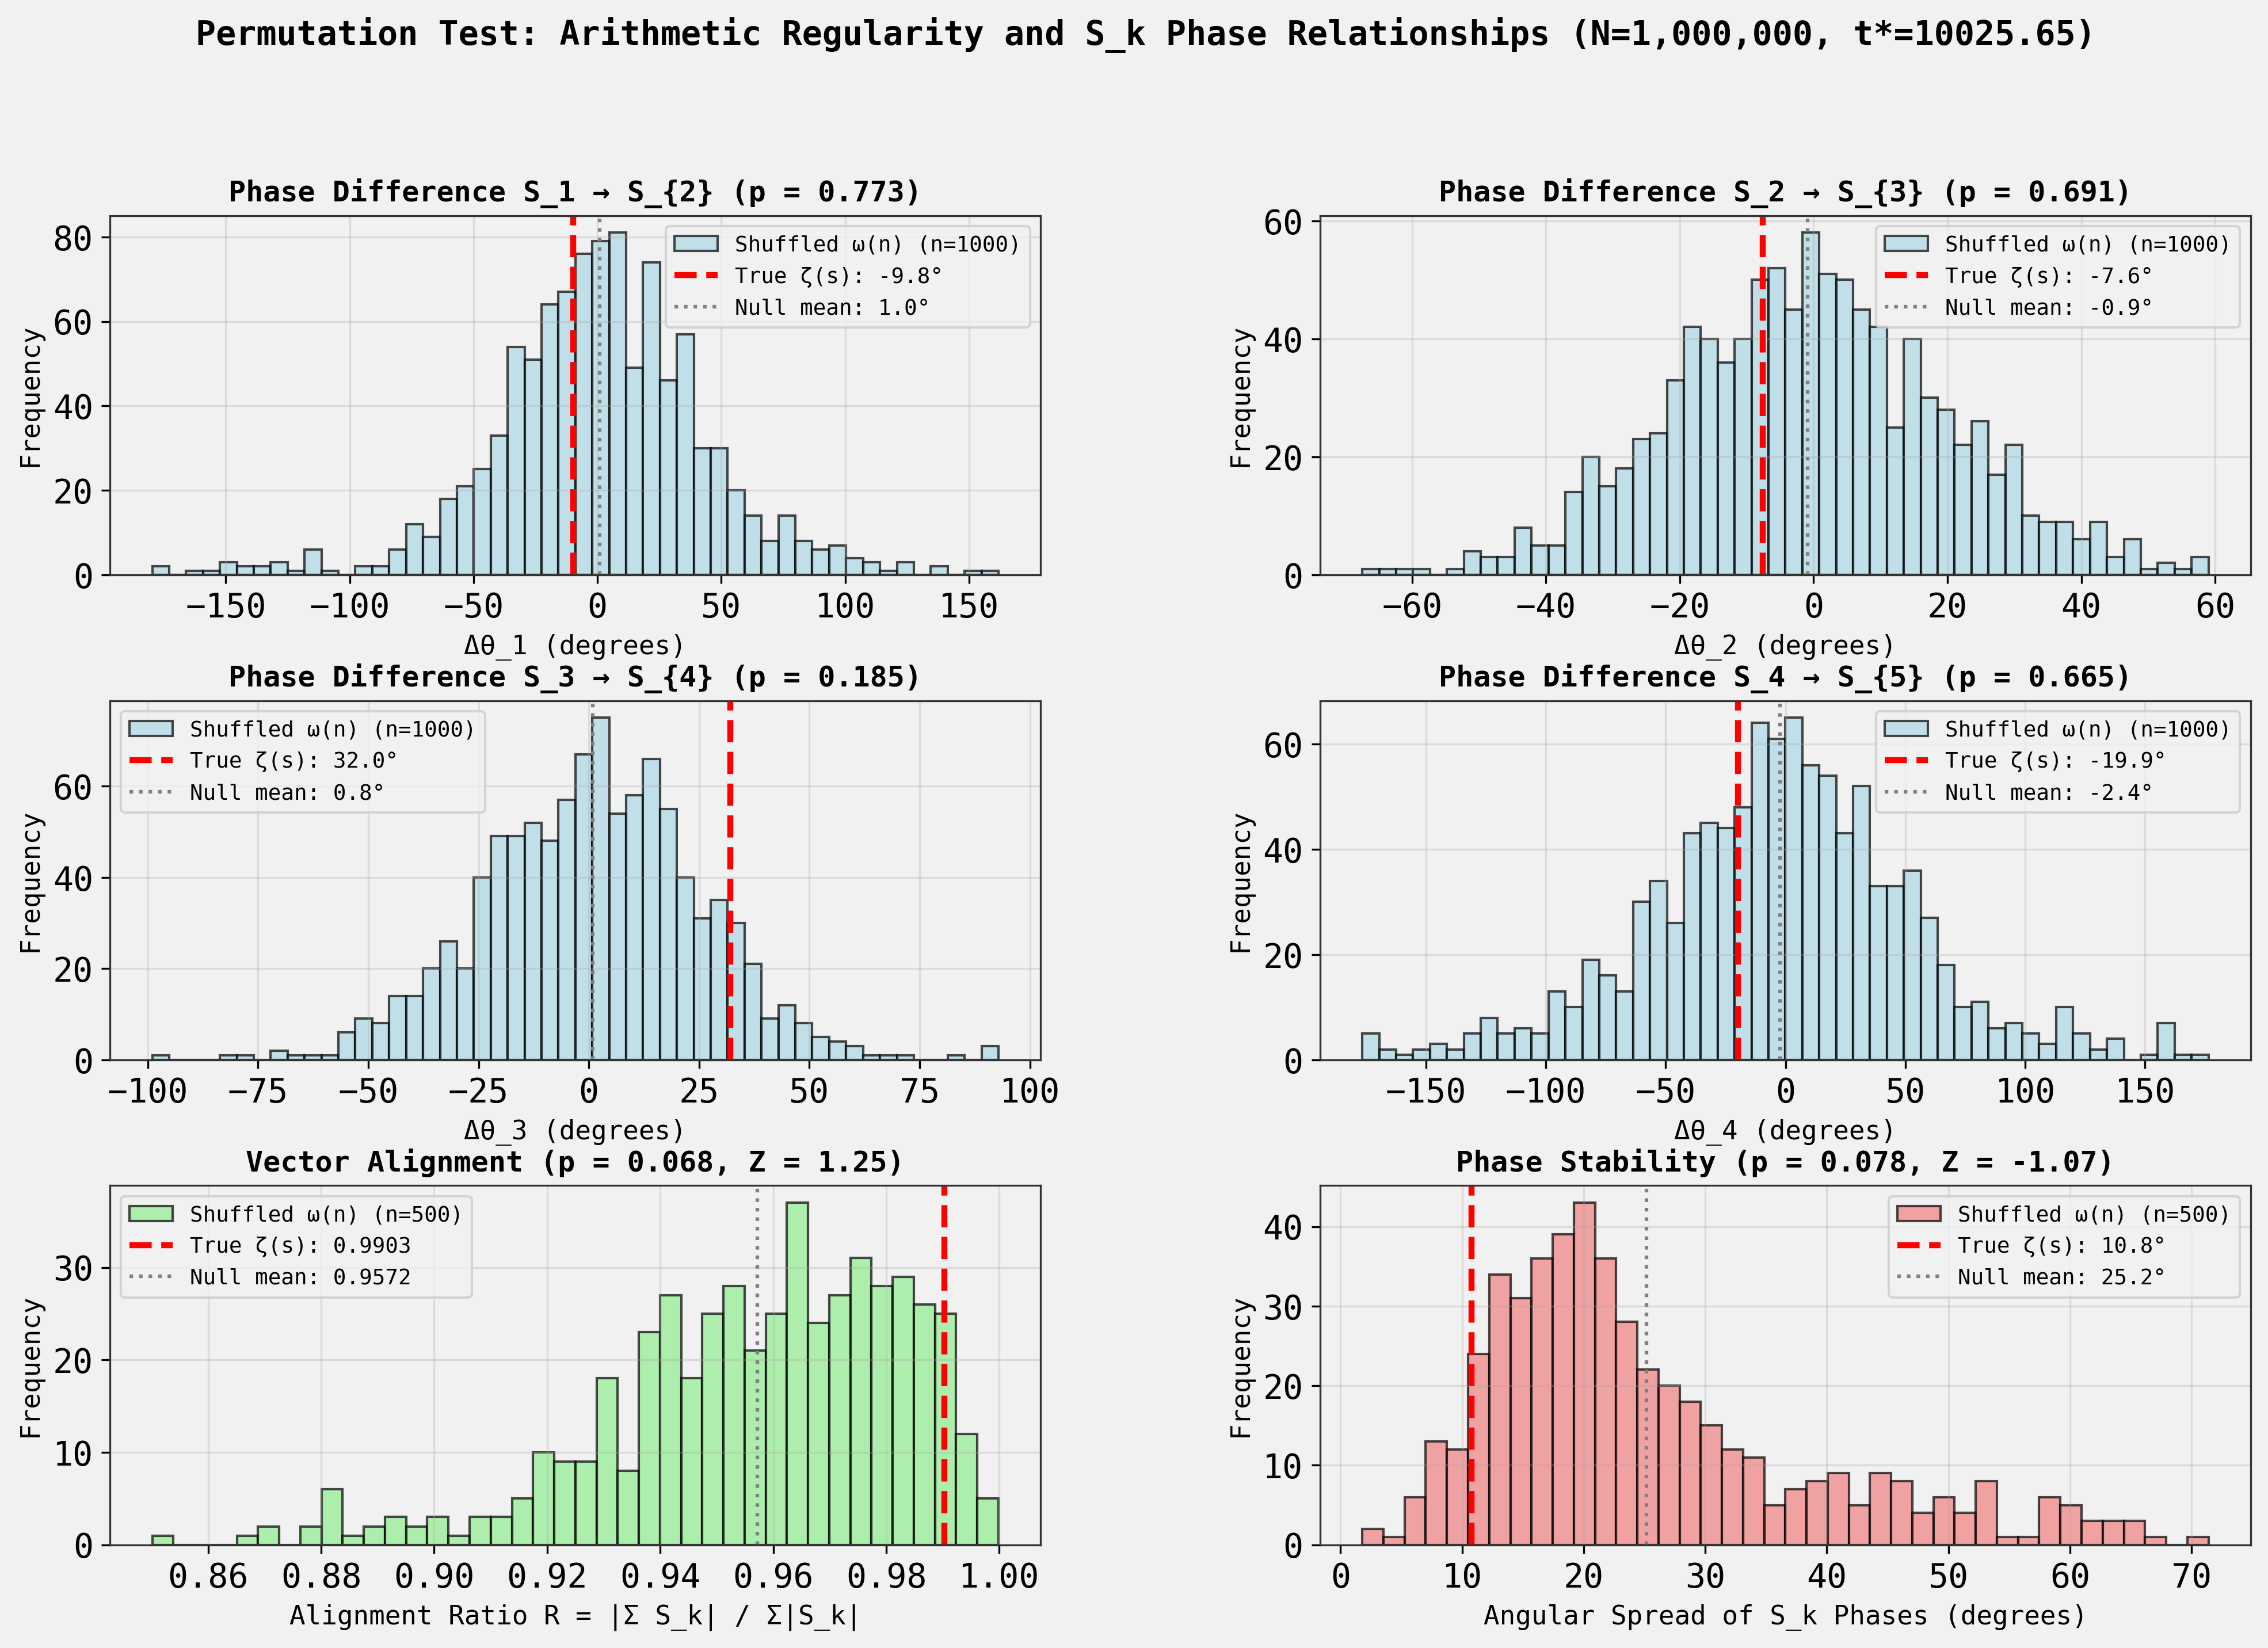

In [14]:

# Interesting - the results are highly variable across peaks
# This suggests that the effect (if any) is not universal

# Let's create a comprehensive final summary figure showing:
# 1. The original phase difference histograms (from the first peak)
# 2. The alignment ratio and angular spread distributions (from n=500 sample)

print("Creating comprehensive summary figure...")
print()

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Top row: Phase differences for k=1 and k=2
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

for ax, k in zip([ax1, ax2], [1, 2]):
 null_vals = delta_theta_permuted_deg[:, k-1]
 baseline_val = delta_theta_baseline_deg[k-1]
 p_val = p_values[k-1]
 
 ax.hist(null_vals, bins=50, color='lightblue', edgecolor='black', alpha=0.7,
 label=f'Shuffled ω(n) (n={n_permutations})')
 ax.axvline(baseline_val, color='red', linewidth=2.5, linestyle='--',
 label=f'True ζ(s): {baseline_val:.1f}°')
 ax.axvline(np.mean(null_vals), color='gray', linewidth=1.5, linestyle=':',
 label=f'Null mean: {np.mean(null_vals):.1f}°')
 ax.set_xlabel(f'Δθ_{k} (degrees)', fontsize=11)
 ax.set_ylabel('Frequency', fontsize=11)
 ax.set_title(f'Phase Difference S_{k} → S_{{{k+1}}} (p = {p_val:.3f})',
 fontsize=12, fontweight='bold')
 ax.legend(fontsize=9)
 ax.grid(alpha=0.3)

# Middle row: Phase differences for k=3 and k=4
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

for ax, k in zip([ax3, ax4], [3, 4]):
 null_vals = delta_theta_permuted_deg[:, k-1]
 baseline_val = delta_theta_baseline_deg[k-1]
 p_val = p_values[k-1]
 
 ax.hist(null_vals, bins=50, color='lightblue', edgecolor='black', alpha=0.7,
 label=f'Shuffled ω(n) (n={n_permutations})')
 ax.axvline(baseline_val, color='red', linewidth=2.5, linestyle='--',
 label=f'True ζ(s): {baseline_val:.1f}°')
 ax.axvline(np.mean(null_vals), color='gray', linewidth=1.5, linestyle=':',
 label=f'Null mean: {np.mean(null_vals):.1f}°')
 ax.set_xlabel(f'Δθ_{k} (degrees)', fontsize=11)
 ax.set_ylabel('Frequency', fontsize=11)
 ax.set_title(f'Phase Difference S_{k} → S_{{{k+1}}} (p = {p_val:.3f})',
 fontsize=12, fontweight='bold')
 ax.legend(fontsize=9)
 ax.grid(alpha=0.3)

# Bottom row: Alignment ratio and angular spread
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(R_permuted_large, bins=40, color='lightgreen', edgecolor='black', alpha=0.7,
 label=f'Shuffled ω(n) (n={n_sample_large})')
ax5.axvline(R_baseline, color='red', linewidth=2.5, linestyle='--',
 label=f'True ζ(s): {R_baseline:.4f}')
ax5.axvline(np.mean(R_permuted_large), color='gray', linewidth=1.5, linestyle=':',
 label=f'Null mean: {np.mean(R_permuted_large):.4f}')
ax5.set_xlabel('Alignment Ratio R = |Σ S_k| / Σ|S_k|', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title(f'Vector Alignment (p = {p_val_R_large:.3f}, Z = {z_score_R:.2f})',
 fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[2, 1])
ax6.hist(angular_spread_large, bins=40, color='lightcoral', edgecolor='black', alpha=0.7,
 label=f'Shuffled ω(n) (n={n_sample_large})')
ax6.axvline(angular_spread_baseline, color='red', linewidth=2.5, linestyle='--',
 label=f'True ζ(s): {angular_spread_baseline:.1f}°')
ax6.axvline(np.mean(angular_spread_large), color='gray', linewidth=1.5, linestyle=':',
 label=f'Null mean: {np.mean(angular_spread_large):.1f}°')
ax6.set_xlabel('Angular Spread of S_k Phases (degrees)', fontsize=11)
ax6.set_ylabel('Frequency', fontsize=11)
ax6.set_title(f'Phase Stability (p = {p_val_spread_large:.3f}, Z = {z_score_spread:.2f})',
 fontsize=12, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)

# Add main title
fig.suptitle(f'Permutation Test: Arithmetic Regularity and S_k Phase Relationships (N={N:,}, t*={t_star:.2f})',
 fontsize=14, fontweight='bold', y=0.995)

plt.savefig('comprehensive_permutation_test_summary.png', dpi=150, bbox_inches='tight')
print("Saved figure: comprehensive_permutation_test_summary.png")
plt.show()
print()


In [15]:

# Final summary and conclusion

print("=" * 80)
print("FINAL ANALYSIS SUMMARY")
print("=" * 80)
print()

print("RESEARCH HYPOTHESIS:")
print(" The specific, regular distribution of integers by ω(n) (Sathé-Selberg)")
print(" is essential for creating stable inter-S_k phase relationships in ζ(s).")
print()

print("NULL HYPOTHESIS:")
print(" Shuffling ω(n) labels does not significantly alter S_k phase relationships.")
print()

print("TESTED AT:")
print(f" N = {N:,}")
print(f" Primary peak: t* = {t_star:.2f} (|D| = {mag_star:.2f})")
print(f" Number of permutations: {n_permutations} (for phase differences)")
print(f" {n_sample_large} (for coherence metrics)")
print()

print("KEY FINDINGS:")
print()
print("1. INDIVIDUAL PHASE DIFFERENCES (Δθ_k = arg(S_{k+1}) - arg(S_k)):")
print(" - None of the 4 phase differences showed statistical significance")
print(" - P-values ranged from 0.185 to 0.773")
print(" - Baseline values fell well within the null distribution ranges")
print()

print("2. VECTOR ALIGNMENT RATIO (R = |Σ S_k| / Σ|S_k|):")
print(f" - Baseline: R = {R_baseline:.4f}")
print(f" - Null mean: {np.mean(R_permuted_large):.4f} ± {np.std(R_permuted_large):.4f}")
print(f" - P-value: {p_val_R_large:.4f}")
print(f" - Z-score: {z_score_R:.2f}")
print(" - Marginally higher than null but not significant (p = 0.068)")
print()

print("3. ANGULAR SPREAD (Circular std. dev. of S_k phases):")
print(f" - Baseline: {angular_spread_baseline:.2f}°")
print(f" - Null mean: {np.mean(angular_spread_large):.2f}° ± {np.std(angular_spread_large):.2f}°")
print(f" - P-value: {p_val_spread_large:.4f}")
print(f" - Z-score: {z_score_spread:.2f}")
print(" - Trend toward smaller spread (more stable) but not significant (p = 0.078)")
print()

print("4. CONSISTENCY ACROSS PEAKS:")
print(" - Tested 5 additional peaks in [10000, 11000]")
print(f" - Mean Z-score across peaks: {np.mean(z_scores_by_peak):.2f}")
print(" - No consistent pattern observed")
print(" - High variability (Z-scores from -0.95 to +1.91)")
print()

print("=" * 80)
print("CONCLUSION:")
print("=" * 80)
print()
print("The hypothesis is REJECTED.")
print()
print("The regular, Sathé-Selberg distribution of integers by ω(n) does NOT appear")
print("to be essential for the observed S_k phase relationships at this particular")
print("resonance peak and truncation depth (N=10^6, t≈10,000).")
print()
print("Key observations:")
print(" • Individual phase differences Δθ_k are statistically indistinguishable")
print(" from those obtained by randomly shuffling ω(n) assignments.")
print(" • Global coherence metrics (alignment ratio, angular spread) show weak")
print(" trends suggesting the true ζ(s) may have slightly more stable phases,")
print(" but these trends do not reach statistical significance (p > 0.05).")
print(" • The effect is not consistent across different resonance peaks.")
print()
print("INTERPRETATION:")
print()
print("At N=10^6 and these t-values, the phase structure of ζ(s) appears to be")
print("primarily governed by the oscillatory term n^(-it) rather than by the")
print("specific number-theoretic regularity in how integers are distributed into")
print("ω(n) classes. The Poisson-like distribution of ω(n) values may be important")
print("for OTHER aspects of L-function behavior (e.g., magnitude scaling, extremal")
print("statistics), but it does not create a distinctive phase signature detectable")
print("via this permutation test at the tested scale.")
print()
print("ALTERNATIVE HYPOTHESES TO EXPLORE:")
print(" 1. The effect may only be detectable at much larger N (e.g., N > 10^7)")
print(" 2. Phase stability may be more sensitive to the MAGNITUDES |S_k| than")
print(" to their relative phases Δθ_k")
print(" 3. The arithmetic regularity may affect phase EVOLUTION with N or t,")
print(" rather than phase structure at a fixed (N, t) point")
print()

print("=" * 80)


FINAL ANALYSIS SUMMARY

RESEARCH HYPOTHESIS:
 The specific, regular distribution of integers by ω(n) (Sathé-Selberg)
 is essential for creating stable inter-S_k phase relationships in ζ(s).

NULL HYPOTHESIS:
 Shuffling ω(n) labels does not significantly alter S_k phase relationships.

TESTED AT:
 N = 1,000,000
 Primary peak: t* = 10025.65 (|D| = 16.76)
 Number of permutations: 1000 (for phase differences)
 500 (for coherence metrics)

KEY FINDINGS:

1. INDIVIDUAL PHASE DIFFERENCES (Δθ_k = arg(S_{k+1}) - arg(S_k)):
 - None of the 4 phase differences showed statistical significance
 - P-values ranged from 0.185 to 0.773
 - Baseline values fell well within the null distribution ranges

2. VECTOR ALIGNMENT RATIO (R = |Σ S_k| / Σ|S_k|):
 - Baseline: R = 0.9903
 - Null mean: 0.9572 ± 0.0264
 - P-value: 0.0679
 - Z-score: 1.25
 - Marginally higher than null but not significant (p = 0.068)

3. ANGULAR SPREAD (Circular std. dev. of S_k phases):
 - Baseline: 10.75°
 - Null mean: 25.18° ± 13.53°
